In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI     
from pydantic import BaseModel, Field
import operator
load_dotenv(dotenv_path='F:\\agentic_ai\\AgenticAIWorkspace\\.env')




True

In [25]:
# model = ChatOpenAI(model_name='gpt-4o mini', temperature=0.7)
model = ChatOpenAI(model_name='gpt-4o' , temperature=0.7)

In [26]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback on the essay.")
    score:int = Field(description="Score out of 10 for the essay.", ge=0, le=10)
    

In [27]:
structured_model = model.with_structured_output(EvaluationSchema)
structured_model

RunnableBinding(bound=ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001ED7E9D00B0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001ED7D2D6EA0>, root_client=<openai.OpenAI object at 0x000001ED7D2EA8A0>, root_async_client=<openai.AsyncOpenAI object at 0x000001ED7D2D7F20>, model_name='gpt-4o', temperature=0.7, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True), kwargs={'response_format': <class '__main__.EvaluationSchema'>, 'ls_structured_output_format': {'kwargs': {'method': 'json_schema', 'strict': None}, 'schema': {'type': 'function', 'function': {'name': 'EvaluationSchema', 'description': '', 'parameters': {'properties': {'feedback': {'description': 'Detailed feedback on the essay.', 'type': 'string'}, 'score': {'description': 'Score out of 10 for the essay.', 'maximum': 10, 'minimum': 0, 'type': 'integer'}}, 'required': ['feedback', 'score'], 'type': 'object'}}}}}, c

In [23]:
essay =""" 
Artificial Intelligence (AI) has become one of the most significant technological advancements of the modern era, transforming the way societies function and economies grow. In India, the role of AI is particularly crucial as the country strives to balance rapid digital transformation with inclusive and sustainable development. With its vast population, growing internet connectivity, and ambitious digital initiatives, India stands at the threshold of an AI-driven revolution that promises to reshape industries, governance, and everyday life.

AI, which refers to the ability of machines to perform tasks that typically require human intelligence, is already making a remarkable impact across multiple sectors in India. In the healthcare sector, AI tools are being used to detect diseases such as tuberculosis and cancer at an early stage, analyze medical images, and assist doctors in providing more accurate diagnoses. These innovations are especially beneficial in rural areas where access to quality healthcare is limited, thus bridging the gap between urban hospitals and remote regions.

In the agricultural sector, which forms the backbone of India’s economy, AI is helping farmers through predictive analytics, crop monitoring, and smart irrigation. With the help of AI-driven applications, farmers can now receive real-time information about weather forecasts, soil health, and pest control. This empowers them to make informed decisions, improve productivity, and reduce losses due to unpredictable climatic conditions.

The role of AI in education is also becoming increasingly important. AI-powered tools are personalizing learning experiences, making education more adaptive to the needs of individual students. India’s “AI for All” initiative, launched in collaboration with the Central Board of Secondary Education (CBSE) and Intel, aims to promote AI literacy among students and teachers, preparing the next generation for the demands of the digital world. Similarly, AI-driven skill development platforms are helping professionals upgrade their competencies for the evolving job market.

In governance, AI is enhancing the efficiency and transparency of public services. From smart city management to fraud detection in financial systems, AI enables the government to make data-driven decisions and improve service delivery. Chatbots and virtual assistants on government websites are making it easier for citizens to access information and complete essential tasks online, reducing bureaucratic delays and improving user experience.

The economic potential of AI in India is immense. Reports suggest that AI could contribute hundreds of billions of dollars to India’s GDP in the coming years. Industries such as finance, retail, logistics, and manufacturing are already leveraging AI for automation, predictive maintenance, and customer engagement. Startups and research institutions are working hand in hand to develop AI-based solutions tailored to India’s unique challenges, ranging from traffic management to disaster prediction.

However, the integration of AI in India also comes with challenges. The country faces a shortage of skilled AI professionals, a lack of high-quality datasets, and concerns over privacy and ethical use of technology. To fully realize the benefits of AI, India must invest in research, education, and digital infrastructure while establishing clear guidelines for responsible and fair use of AI technologies.

In conclusion, Artificial Intelligence has the potential to become a powerful force for progress in India. It can drive economic growth, improve public welfare, and create new opportunities for innovation and employment. With the right balance of policy, education, and ethics, India can harness the power of AI to build a future that is intelligent, inclusive, and sustainable. AI is not just about machines making decisions; it is about using technology to empower people, enhance lives, and accelerate the nation’s journey toward becoming a global leader in the digital age.
"""

In [65]:
prompt = f""" Evaluate the language quality of the following essay and provide a feedback and assign 
a score out of 10 \n {essay}"

"""
structured_model.invoke(prompt)



EvaluationSchema(feedback='The essay is well-structured and presents a comprehensive overview of the impact and potential of Artificial Intelligence (AI) in India. Here is a detailed evaluation of its language quality:\n\n### Strengths\n1. **Clarity and Coherence:**\n   - The essay is clear and logically structured, guiding the reader through various sectors where AI plays a role in India.\n   - Each paragraph focuses on a specific area, ensuring coherence and easy flow of ideas.\n\n2. **Comprehensive Coverage:**\n   - The essay covers multiple sectors, including healthcare, agriculture, education, governance, and the economy, providing a holistic view of AI\'s influence.\n   - It also discusses the challenges associated with AI adoption, adding depth to the analysis.\n\n3. **Use of Examples and Data:**\n   - By mentioning specific initiatives like "AI for All" and the collaboration with CBSE and Intel, the essay effectively illustrates its points.\n   - References to reports predictin

In [50]:
class UPSCState(TypedDict):
    essay:str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_score : Annotated[list[int], operator.add]
    avg_score: float

In [51]:
def evaluate_language(state:UPSCState) -> UPSCState:
    prompt = f""" Evaluate the language quality of the following essay and provide a feedback and assign 
    a score out of 10 \n {state['essay']}"
    
    """
    result = structured_model.invoke(prompt)
    # state['language_feedback'] = result.feedback
    # state['individual_score'].append(result.score)
    return {    'language_feedback': result.feedback,
                'individual_score': [result.score]}

In [ ]:
def evaluate_analysis(state:UPSCState) -> UPSCState:
    prompt = f""" Evaluate the content quality and depth of analysis of the following essay and provide a feedback and assign 
    a score out of 10 \n {state['essay']}"  
    
    """
    result = structured_model.invoke(prompt)
    # state['analysis_feedback'] = result.feedback
    # state['individual_score'].append(result.score)
    return {    'analysis_feedback': result.feedback,
                'individual_score': [result.score]}

In [53]:
def evaluate_clarity(state:UPSCState) -> UPSCState:
    prompt = f""" Evaluate the clarity and coherence of the following essay and provide a feedback and assign 
    a score out of 10 \n {state['essay']}"  
    
    """
    result = structured_model.invoke(prompt)
    # state['clarity_feedback'] = result.feedback
    # state['individual_score'].append(result.score)
    return {    'clarity_feedback': result.feedback,
                'individual_score': [result.score]}

In [60]:
def final_evaluation(state:UPSCState) -> UPSCState:
    avg_score = sum(state['individual_score']) / len(state['individual_score'])
    prompt = f""" Provide an overall evaluation of the essay based on the following feedbacks:
    Language Feedback: {state['language_feedback']}
    Analysis Feedback: {state['analysis_feedback']}
    Clarity Feedback: {state['clarity_feedback']}
    
    Also, provide suggestions for improvement.
    """
    overall_feedback = model.invoke(prompt)
    
    return {    'overall_feedback': overall_feedback,
                'avg_score': avg_score}

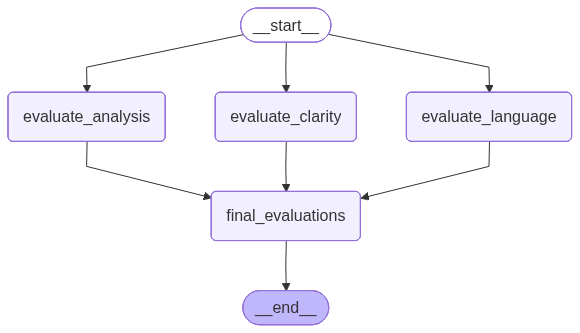

In [61]:
graph =  StateGraph(UPSCState)

# add nodes
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('final_evaluations', final_evaluation)

#add edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_clarity')
graph.add_edge('evaluate_language', 'final_evaluations')
graph.add_edge('evaluate_analysis', 'final_evaluations')
graph.add_edge('evaluate_clarity', 'final_evaluations')
graph.add_edge('final_evaluations', END)

workflow = graph.compile()
workflow

In [62]:
initial_state: UPSCState = {
    'essay': essay}
workflow.invoke(initial_state)

{'essay': ' \nArtificial Intelligence (AI) has become one of the most significant technological advancements of the modern era, transforming the way societies function and economies grow. In India, the role of AI is particularly crucial as the country strives to balance rapid digital transformation with inclusive and sustainable development. With its vast population, growing internet connectivity, and ambitious digital initiatives, India stands at the threshold of an AI-driven revolution that promises to reshape industries, governance, and everyday life.\n\nAI, which refers to the ability of machines to perform tasks that typically require human intelligence, is already making a remarkable impact across multiple sectors in India. In the healthcare sector, AI tools are being used to detect diseases such as tuberculosis and cancer at an early stage, analyze medical images, and assist doctors in providing more accurate diagnoses. These innovations are especially beneficial in rural areas 

In [63]:
eassay_with_mistakes = """ 
Artifical inteligence is very importent for india now a days. It is using in many area like hospitals, schools, farming and even in goverment works. Many companys are making robots and smart machines which can think like humans and do work faster then people.

In hospitals AI help doctors to find disease early and also help in surgerys. In villages farmers use AI app for knowing about weather and crop but still many people dont know how to use it properly. In education AI make study more easy but some students become lazy because of it.

Indian goverment is also trying to use AI for traffic, city cleaning and police system. But there are also many problem like people dont have much knowledge, internet not good in all place and AI cost too much money.

Still, if India use AI in good way it can make our country more smart and develop faster then before.
"""

In [64]:
initial_state: UPSCState = {
    'essay': eassay_with_mistakes}
workflow.invoke(initial_state)

{'essay': ' \nArtifical inteligence is very importent for india now a days. It is using in many area like hospitals, schools, farming and even in goverment works. Many companys are making robots and smart machines which can think like humans and do work faster then people.\n\nIn hospitals AI help doctors to find disease early and also help in surgerys. In villages farmers use AI app for knowing about weather and crop but still many people dont know how to use it properly. In education AI make study more easy but some students become lazy because of it.\n\nIndian goverment is also trying to use AI for traffic, city cleaning and police system. But there are also many problem like people dont have much knowledge, internet not good in all place and AI cost too much money.\n\nStill, if India use AI in good way it can make our country more smart and develop faster then before.\n',
 'language_feedback': '**Feedback:**\n\n1. **Spelling and Grammar:**\n   - There are several spelling mistakes, 